In [8]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [11]:
YEAR = 2023

In [12]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.55

In [13]:
base_path = f'../../data/{NUTS2}/results/'

In [14]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Attica_Results_2010-2022.csv',
 'GR_Attica_Results_2023-August-1st.csv',
 'GR_Attica_Results_2023-July-1st.csv',
 'GR_Attica_Results_2023-July-2nd.csv',
 'GR_Attica_Results_2023-June-1st.csv',
 'GR_Attica_Results_2023-June-2nd.csv',
 'GR_Attica_Results_2023-May-1st.csv',
 'GR_Attica_Results_2023-May-2nd.csv']

In [15]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y', 'case'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [16]:
data

,lau1,day,month,year,score
0,πορου,1,8,2019,9.999924e-01
1,πορου,16,7,2019,9.999822e-01
2,πορου,16,8,2019,9.999797e-01
3,πορου,1,9,2019,9.999762e-01
4,πορου,1,7,2019,9.999705e-01
...,...,...,...,...,...
12007,κυθηρων,1,5,2012,3.523577e-09
12008,κυθηρων,1,5,2016,1.642235e-09
12009,κυθηρων,16,5,2021,1.401052e-09
12010,κυθηρων,16,11,2021,1.198495e-09


In [17]:
data_og = data.copy()

In [18]:
np.sort(data.month.unique())

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [19]:
np.sort(data.year.unique())

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [20]:
zero_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'score': 0}
one_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'score': 1}

In [21]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [22]:
data

,lau1,day,month,year,score
0,πορου,1,8,2019,9.999924e-01
1,πορου,16,7,2019,9.999822e-01
2,πορου,16,8,2019,9.999797e-01
3,πορου,1,9,2019,9.999762e-01
4,πορου,1,7,2019,9.999705e-01
...,...,...,...,...,...
12009,κυθηρων,16,5,2021,1.401052e-09
12010,κυθηρων,16,11,2021,1.198495e-09
12011,κυθηρων,1,5,2021,1.833233e-10
12012,αγνωστη,0,0,0,0.000000e+00


In [23]:
data_sorted = data.sort_values(by='score', ascending=True)

In [24]:
data_sorted.reset_index(drop = True, inplace = True)

In [25]:
data_sorted

,lau1,day,month,year,score
0,αγνωστη,0,0,0,0.000000e+00
1,κυθηρων,1,5,2021,1.833233e-10
2,κυθηρων,16,11,2021,1.198495e-09
3,κυθηρων,16,5,2021,1.401052e-09
4,κυθηρων,1,5,2016,1.642235e-09
...,...,...,...,...,...
12009,πορου,1,9,2019,9.999762e-01
12010,πορου,16,8,2019,9.999797e-01
12011,πορου,16,7,2019,9.999822e-01
12012,πορου,1,8,2019,9.999924e-01


<AxesSubplot:>

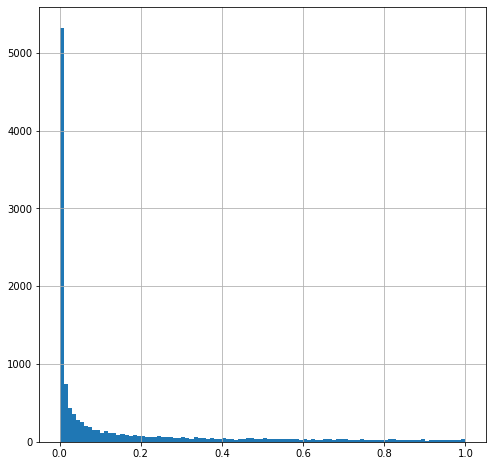

In [26]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [27]:
number_of_observations = len(data_sorted)

In [28]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

5420

In [29]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 5420 observations
Class 1: 2981 observations
Class 2: 1640 observations
Class 3: 902 observations
Class 4: 496 observations
Class 5: 273 observations
Class 6: 150 observations
Class 7: 82 observations
Class 8: 45 observations
Class 9: 25 observations

Total Observations: 12014


In [30]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [31]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    5420
1    2981
2    1640
3     902
4     496
5     273
6     150
7      82
8      45
9      23
Name: risk_class, dtype: int64

In [32]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0110', '0.1259', '0.3715', '0.6084', '0.7758', '0.8790', '0.9379', '0.9773', '0.9935', '1.0000']


In [33]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(bins)